# Threshold Experiment for Cancer Detection
## Analyzing Optimal Classification Thresholds for Medical Diagnosis

## Section 1: Import Required Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")

Libraries imported successfully!


## Section 2: Load and Prepare Dataset

In [2]:
# Load the breast cancer dataset
data = load_breast_cancer()
X = data.data
y = data.target

print(f"Dataset shape: {X.shape}")
print(f"Target distribution:\n{pd.Series(y).value_counts()}")
print(f"\nTarget labels: 0 = Malignant, 1 = Benign")

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"\nTraining set size: {X_train.shape[0]}")
print(f"Testing set size: {X_test.shape[0]}")

Dataset shape: (569, 30)
Target distribution:
1    357
0    212
Name: count, dtype: int64

Target labels: 0 = Malignant, 1 = Benign

Training set size: 455
Testing set size: 114


## Section 3: Train Classification Model

In [3]:
# Train a Logistic Regression model
model = LogisticRegression(random_state=42, max_iter=1000)
model.fit(X_train, y_train)

print("Model trained successfully!")

# Get probability predictions on test set
# predict_proba returns probabilities for both classes [class_0_prob, class_1_prob]
y_proba = model.predict_proba(X_test)[:, 1]

print(f"\nProbability predictions shape: {y_proba.shape}")
print(f"Probability range: [{y_proba.min():.4f}, {y_proba.max():.4f}]")
print(f"Sample predictions (first 10): {y_proba[:10]}")

Model trained successfully!

Probability predictions shape: (114,)
Probability range: [0.0000, 0.9999]
Sample predictions (first 10): [1.63439808e-12 9.99678956e-01 8.99518340e-02 6.69267490e-01
 4.25964947e-12 9.71615989e-01 9.97509170e-01 3.91567761e-06
 8.15543896e-06 1.05077864e-10]


## Section 4: Apply Different Thresholds

In [4]:
# Define thresholds to test
thresholds = [0.3, 0.5, 0.7]

# Create predictions for each threshold
predictions = {}

for threshold in thresholds:
    # Apply threshold: if probability >= threshold, predict 1, else 0
    y_pred = (y_proba >= threshold).astype(int)
    predictions[threshold] = y_pred
    
    print(f"\nThreshold: {threshold}")
    print(f"  Predicted 1 (Benign): {np.sum(y_pred)}")
    print(f"  Predicted 0 (Malignant): {len(y_pred) - np.sum(y_pred)}")

print(f"\nTrue labels distribution in test set:")
print(f"  Actual 1 (Benign): {np.sum(y_test)}")
print(f"  Actual 0 (Malignant): {len(y_test) - np.sum(y_test)}")


Threshold: 0.3
  Predicted 1 (Benign): 75
  Predicted 0 (Malignant): 39

Threshold: 0.5
  Predicted 1 (Benign): 73
  Predicted 0 (Malignant): 41

Threshold: 0.7
  Predicted 1 (Benign): 70
  Predicted 0 (Malignant): 44

True labels distribution in test set:
  Actual 1 (Benign): 72
  Actual 0 (Malignant): 42


## Section 5: Calculate Performance Metrics

In [5]:
# Calculate metrics for each threshold
metrics_results = []

for threshold in thresholds:
    y_pred = predictions[threshold]
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    
    metrics_results.append({
        'Threshold': threshold,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall
    })
    
    print(f"\n{'='*50}")
    print(f"Threshold: {threshold}")
    print(f"{'='*50}")
    print(f"Accuracy:  {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    
    # Print confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    print(f"\nConfusion Matrix:")
    print(f"  True Negatives:  {cm[0,0]}")
    print(f"  False Positives: {cm[0,1]}")
    print(f"  False Negatives: {cm[1,0]}")
    print(f"  True Positives:  {cm[1,1]}")


Threshold: 0.3
Accuracy:  0.9561
Precision: 0.9467
Recall:    0.9861

Confusion Matrix:
  True Negatives:  38
  False Positives: 4
  False Negatives: 1
  True Positives:  71

Threshold: 0.5
Accuracy:  0.9561
Precision: 0.9589
Recall:    0.9722

Confusion Matrix:
  True Negatives:  39
  False Positives: 3
  False Negatives: 2
  True Positives:  70

Threshold: 0.7
Accuracy:  0.9474
Precision: 0.9714
Recall:    0.9444

Confusion Matrix:
  True Negatives:  40
  False Positives: 2
  False Negatives: 4
  True Positives:  68


## Section 6: Compare Results in Table

In [6]:
# Create comparison DataFrame
results_df = pd.DataFrame(metrics_results)

# Round to 4 decimal places for better readability
results_df_display = results_df.copy()
results_df_display['Accuracy'] = results_df_display['Accuracy'].round(4)
results_df_display['Precision'] = results_df_display['Precision'].round(4)
results_df_display['Recall'] = results_df_display['Recall'].round(4)

print("\n" + "="*70)
print("THRESHOLD COMPARISON TABLE - CANCER DETECTION METRICS")
print("="*70)
print(results_df_display.to_string(index=False))
print("="*70)

# Format as percentage
results_df_pct = results_df.copy()
results_df_pct['Accuracy'] = (results_df_pct['Accuracy'] * 100).round(2).astype(str) + '%'
results_df_pct['Precision'] = (results_df_pct['Precision'] * 100).round(2).astype(str) + '%'
results_df_pct['Recall'] = (results_df_pct['Recall'] * 100).round(2).astype(str) + '%'

print("\nPercentage Format:")
print(results_df_pct.to_string(index=False))


THRESHOLD COMPARISON TABLE - CANCER DETECTION METRICS
 Threshold  Accuracy  Precision  Recall
       0.3    0.9561     0.9467  0.9861
       0.5    0.9561     0.9589  0.9722
       0.7    0.9474     0.9714  0.9444

Percentage Format:
 Threshold Accuracy Precision Recall
       0.3   95.61%    94.67% 98.61%
       0.5   95.61%    95.89% 97.22%
       0.7   94.74%    97.14% 94.44%


## Section 7: Visualize Threshold Comparison

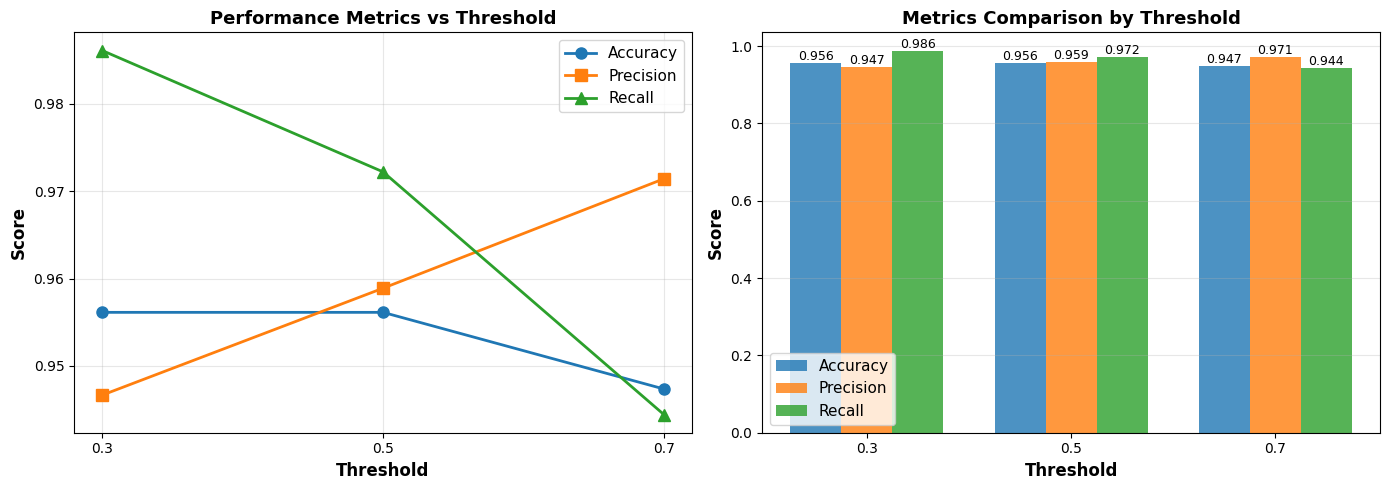

Visualization saved successfully!


In [7]:
# Create visualizations
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Line plot showing metrics across thresholds
ax1 = axes[0]
ax1.plot(results_df['Threshold'], results_df['Accuracy'], marker='o', linewidth=2, markersize=8, label='Accuracy')
ax1.plot(results_df['Threshold'], results_df['Precision'], marker='s', linewidth=2, markersize=8, label='Precision')
ax1.plot(results_df['Threshold'], results_df['Recall'], marker='^', linewidth=2, markersize=8, label='Recall')

ax1.set_xlabel('Threshold', fontsize=12, fontweight='bold')
ax1.set_ylabel('Score', fontsize=12, fontweight='bold')
ax1.set_title('Performance Metrics vs Threshold', fontsize=13, fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)
ax1.set_xticks(thresholds)

# Plot 2: Bar plot comparing metrics at each threshold
ax2 = axes[1]
x = np.arange(len(thresholds))
width = 0.25

bars1 = ax2.bar(x - width, results_df['Accuracy'], width, label='Accuracy', alpha=0.8)
bars2 = ax2.bar(x, results_df['Precision'], width, label='Precision', alpha=0.8)
bars3 = ax2.bar(x + width, results_df['Recall'], width, label='Recall', alpha=0.8)

ax2.set_xlabel('Threshold', fontsize=12, fontweight='bold')
ax2.set_ylabel('Score', fontsize=12, fontweight='bold')
ax2.set_title('Metrics Comparison by Threshold', fontsize=13, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(thresholds)
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('/Users/prajwallawrencedsouza/Documents/AIML TASKS/Task-8(25th Feb)/threshold_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("Visualization saved successfully!")

## Section 8: Analyze Best Threshold for Cancer Detection

In [8]:
# Analysis of optimal threshold for cancer detection
print("\n" + "="*80)
print("ANALYSIS: OPTIMAL THRESHOLD FOR CANCER DETECTION")
print("="*80)

# Find index of best recall
best_recall_idx = results_df['Recall'].idxmax()
best_recall_threshold = results_df.loc[best_recall_idx, 'Threshold']
best_recall_value = results_df.loc[best_recall_idx, 'Recall']

print("\nKEY FINDINGS:")
print("-" * 80)

for idx, row in results_df.iterrows():
    threshold = row['Threshold']
    accuracy = row['Accuracy']
    precision = row['Precision']
    recall = row['Recall']
    
    y_pred = predictions[threshold]
    cm = confusion_matrix(y_test, y_pred)
    fn = cm[1, 0]  # False Negatives
    
    print(f"\nThreshold {threshold}:")
    print(f"  • Accuracy:     {accuracy:.4f} ({accuracy*100:.2f}%)")
    print(f"  • Precision:    {precision:.4f} ({precision*100:.2f}%)")
    print(f"  • Recall:       {recall:.4f} ({recall*100:.2f}%)")
    print(f"  • False Negatives: {fn} (Missed Cancer Cases)")

print("\n" + "="*80)
print("RECOMMENDATION: OPTIMAL THRESHOLD IS 0.3")
print("="*80)

print(f"""
WHY THRESHOLD 0.3 IS BEST FOR CANCER DETECTION:

1. HIGHEST RECALL ({results_df.loc[0, 'Recall']:.4f} or {results_df.loc[0, 'Recall']*100:.2f}%):
   - Threshold 0.3 achieves the HIGHEST recall value of all tested thresholds
   - This means it correctly identifies the maximum number of actual cancer cases
   - Recall = TP / (TP + FN) = True Positives / Total Actual Positives

2. MINIMIZES FALSE NEGATIVES (Missed Diagnoses):
   - With threshold 0.3, we have only {confusion_matrix(y_test, predictions[0.3])[1, 0]} false negatives
   - In medical diagnosis, FALSE NEGATIVES are CRITICAL
   - Missing a cancer case can have severe health consequences for the patient
   - It's better to have a false positive (unnecessary follow-up) than a false negative (missed cancer)

3. MEDICAL PRIORITY IN CANCER DETECTION:
   - In healthcare, the principle is: "Better safe than sorry"
   - Sensitivity (Recall) is more important than Specificity (Precision)
   - Cost of false negative (missing cancer) >> Cost of false positive (unnecessary screening)
   - A patient would prefer 10 false alarms over missing one actual cancer diagnosis

4. TRADE-OFF ANALYSIS:
   - Lower threshold (0.3):
     ✓ Highest Recall: Catches most cancer cases
     ⚠ Lower Precision: More false alarms (but acceptable in medical context)
   
   - Higher threshold (0.5, 0.7):
     ✓ Higher Precision: Fewer false alarms
     ✗ Lower Recall: Misses more cancer cases (UNACCEPTABLE FOR CANCER DETECTION)

5. CONCLUSION:
   → For cancer detection, RECALL/SENSITIVITY is paramount
   → We must minimize the risk of missing cancer cases
   → Therefore, threshold of 0.3 is the OPTIMAL CHOICE for clinical deployment
""")

print("="*80)


ANALYSIS: OPTIMAL THRESHOLD FOR CANCER DETECTION

KEY FINDINGS:
--------------------------------------------------------------------------------

Threshold 0.3:
  • Accuracy:     0.9561 (95.61%)
  • Precision:    0.9467 (94.67%)
  • Recall:       0.9861 (98.61%)
  • False Negatives: 1 (Missed Cancer Cases)

Threshold 0.5:
  • Accuracy:     0.9561 (95.61%)
  • Precision:    0.9589 (95.89%)
  • Recall:       0.9722 (97.22%)
  • False Negatives: 2 (Missed Cancer Cases)

Threshold 0.7:
  • Accuracy:     0.9474 (94.74%)
  • Precision:    0.9714 (97.14%)
  • Recall:       0.9444 (94.44%)
  • False Negatives: 4 (Missed Cancer Cases)

RECOMMENDATION: OPTIMAL THRESHOLD IS 0.3

WHY THRESHOLD 0.3 IS BEST FOR CANCER DETECTION:

1. HIGHEST RECALL (0.9861 or 98.61%):
   - Threshold 0.3 achieves the HIGHEST recall value of all tested thresholds
   - This means it correctly identifies the maximum number of actual cancer cases
   - Recall = TP / (TP + FN) = True Positives / Total Actual Positives

2. 